In [1]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
print("Dataset downloaded at:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Dataset downloaded at: /kaggle/input/flowers-recognition


In [2]:
from pathlib import Path

CLASS_NAMES = ["daisy", "dandelion", "rose", "sunflower", "tulip"]

root = Path(path)
candidates = []

for d in root.rglob("*"):
    if d.is_dir() and all((d / c).exists() for c in CLASS_NAMES):
        candidates.append(d)

assert len(candidates) > 0, "Could not find flower dataset folder."

DATA_DIR = str(candidates[0])

print("DATA_DIR:", DATA_DIR)
print("Folders:", [p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])

DATA_DIR: /kaggle/input/flowers-recognition/flowers
Folders: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


In [3]:
import os
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports loaded successfully.")

Imports loaded successfully.


In [4]:
X = []
Z = []
IMG_SIZE = 150

def assign_label(img, flower_type):
    return flower_type

def make_train_data(flower_type, DIR):
    for img in tqdm(os.listdir(DIR)):
        label = assign_label(img, flower_type)
        path = os.path.join(DIR, img)
        try:
            img_array = cv2.imread(path)
            img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            X.append(np.array(img_array))
            Z.append(str(label))
        except:
            pass

for cls in CLASS_NAMES:
    make_train_data(cls, os.path.join(DATA_DIR, cls))

print("Total images loaded:", len(X))

100%|██████████| 984/984 [00:02<00:00, 398.64it/s]

Total images loaded: 4317


In [5]:
print("Total number of images:", len(X))

class_counts = Counter(Z)
print("\nImages per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Total number of images: 4317

Images per class:
daisy: 764
dandelion: 1052
rose: 784
sunflower: 733
tulip: 984


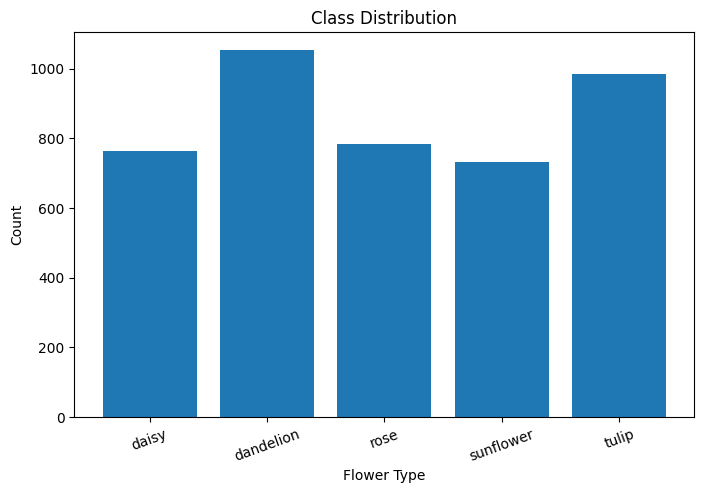

In [6]:
counts = Counter(Z)

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Flower Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

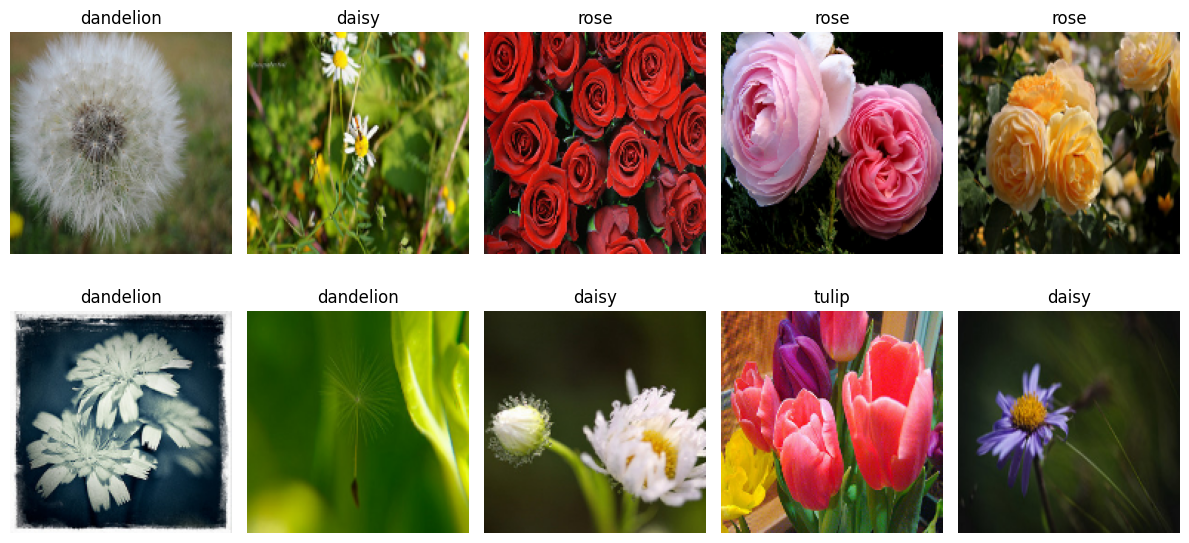

In [7]:
def show_random_samples(X, Z, n=10):
    idxs = random.sample(range(len(X)), n)
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, 5, i + 1)
        plt.imshow(cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB))
        plt.title(Z[idx])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_samples(X, Z, n=10)

In [8]:
print("Sample image shape:", X[0].shape)
print("Data type:", X[0].dtype)
print("Minimum pixel value:", X[0].min())
print("Maximum pixel value:", X[0].max())

Sample image shape: (150, 150, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [9]:
X = np.array(X)
Z = np.array(Z)

print("X shape before split:", X.shape)
print("Z shape before encoding:", Z.shape)

le = LabelEncoder()
Y = le.fit_transform(Z)
Y = to_categorical(Y, 5)

print("\nEncoded classes:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls} -> {idx}")

print("\nY shape after one-hot encoding:", Y.shape)

X shape before split: (4317, 150, 150, 3)
Z shape before encoding: (4317,)

Encoded classes:
daisy -> 0
dandelion -> 1
rose -> 2
sunflower -> 3
tulip -> 4

Y shape after one-hot encoding: (4317, 5)


In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y
)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

x_train shape: (3237, 150, 150, 3)
y_train shape: (3237, 5)
x_test shape : (1080, 150, 150, 3)
y_test shape : (1080, 5)


In [11]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

print("After validation split:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape  :", x_val.shape)
print("y_val shape  :", y_val.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

After validation split:
x_train shape: (2589, 150, 150, 3)
y_train shape: (2589, 5)
x_val shape  : (648, 150, 150, 3)
y_val shape  : (648, 5)
x_test shape : (1080, 150, 150, 3)
y_test shape : (1080, 5)


In [12]:
x_train_tf = x_train.astype("float32") / 255.0
x_val_tf   = x_val.astype("float32") / 255.0
x_test_tf  = x_test.astype("float32") / 255.0

print("TensorFlow-ready arrays:")
print("x_train_tf:", x_train_tf.shape, x_train_tf.dtype)
print("x_val_tf  :", x_val_tf.shape, x_val_tf.dtype)
print("x_test_tf :", x_test_tf.shape, x_test_tf.dtype)

TensorFlow-ready arrays:
x_train_tf: (2589, 150, 150, 3) float32
x_val_tf  : (648, 150, 150, 3) float32
x_test_tf : (1080, 150, 150, 3) float32


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model

tf.random.set_seed(42)

IMG_SIZE_TF = 224

# Resize images for ResNet50
x_train_resized = tf.image.resize(x_train_tf, (IMG_SIZE_TF, IMG_SIZE_TF))
x_val_resized   = tf.image.resize(x_val_tf, (IMG_SIZE_TF, IMG_SIZE_TF))
x_test_resized  = tf.image.resize(x_test_tf, (IMG_SIZE_TF, IMG_SIZE_TF))

# Apply preprocessing
x_train_resized = tf.keras.applications.resnet50.preprocess_input(x_train_resized * 255.0)
x_val_resized   = tf.keras.applications.resnet50.preprocess_input(x_val_resized * 255.0)
x_test_resized  = tf.keras.applications.resnet50.preprocess_input(x_test_resized * 255.0)

# Load pretrained model
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
output = Dense(5, activation="softmax")(x)

tf_model = Model(inputs=base_model.input, outputs=output)

# Compile model
tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show summary
tf_model.summary()
print("Total parameters:", tf_model.count_params())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Total parameters: 24113541


In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_tf = tf_model.fit(
    x_train_resized,
    y_train,
    validation_data=(x_val_resized, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 38s 297ms/step - accuracy: 0.7710 - loss: 0.6742 - val_accuracy: 0.8904 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.8895 - loss: 0.3012 - val_accuracy: 0.8997 - val_loss: 0.3025 - learning_rate: 0.0010
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.9146 - loss: 0.2300 - val_accuracy: 0.8827 - val_loss: 0.3531 - learning_rate: 0.0010
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9306 - loss: 0.1905
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.9363 - loss: 0.1772 - val_accuracy: 0.8642 - val_loss: 0.3763 - learning_rate: 0.0010
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.9540 - loss: 0.1391 - val_accuracy: 0.8920 - val_loss: 0.3166 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


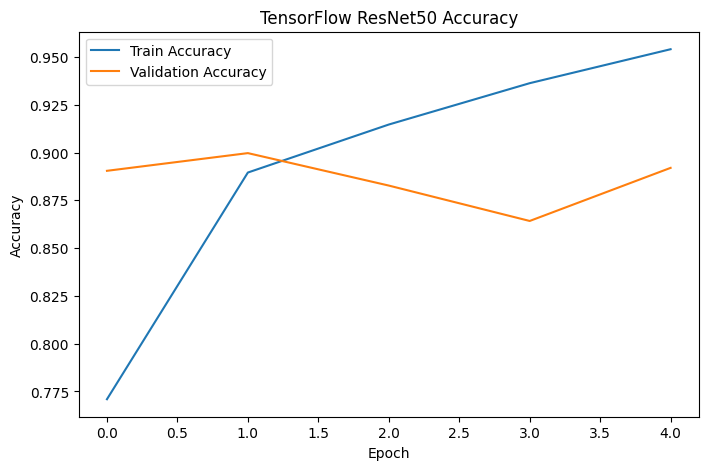

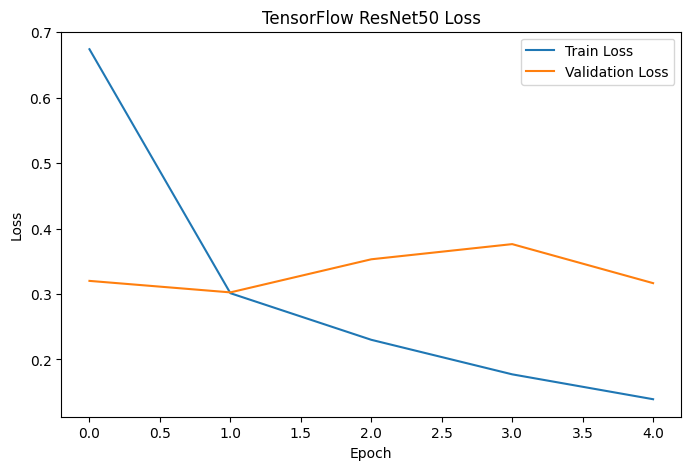

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_tf.history["accuracy"], label="Train Accuracy")
plt.plot(history_tf.history["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_tf.history["loss"], label="Train Loss")
plt.plot(history_tf.history["val_loss"], label="Validation Loss")
plt.title("TensorFlow ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Predictions
y_pred_probs_tf = tf_model.predict(x_test_resized)
y_pred_tf = np.argmax(y_pred_probs_tf, axis=1)
y_true_tf = np.argmax(y_test, axis=1)

# Metrics
tf_acc = accuracy_score(y_true_tf, y_pred_tf)
tf_prec, tf_rec, tf_f1, _ = precision_recall_fscore_support(
    y_true_tf, y_pred_tf, average="macro"
)

print("TensorFlow Test Accuracy:", tf_acc)
print("TensorFlow Precision:", tf_prec)
print("TensorFlow Recall:", tf_rec)
print("TensorFlow F1-score:", tf_f1)

print("\nClassification Report:\n")
print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))

34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 265ms/step
TensorFlow Test Accuracy: 0.8601851851851852
TensorFlow Precision: 0.8622841251541746
TensorFlow Recall: 0.853887727789966
TensorFlow F1-score: 0.8568785222370634

Classification Report:

              precision    recall  f1-score   support

       daisy       0.89      0.84      0.86       191
   dandelion       0.89      0.91      0.90       263
        rose       0.83      0.76      0.79       196
   sunflower       0.89      0.85      0.87       184
       tulip       0.81      0.91      0.86       246

    accuracy                           0.86      1080
   macro avg       0.86      0.85      0.86      1080
weighted avg       0.86      0.86      0.86      1080



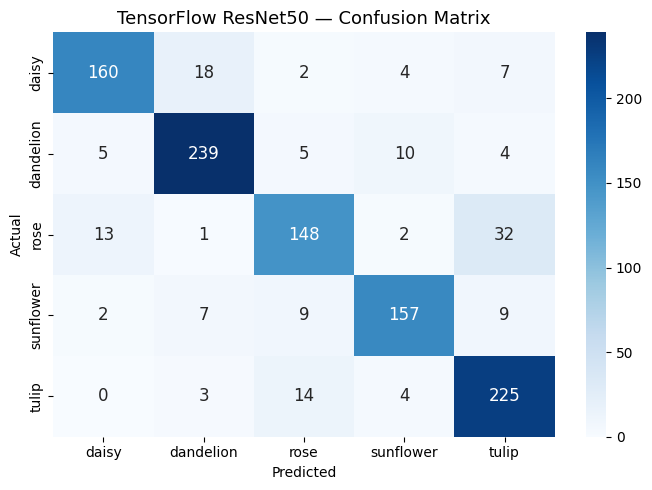

In [17]:
import seaborn as sns

cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            annot_kws={"size": 12})
plt.title("TensorFlow ResNet50 — Confusion Matrix", fontsize=13)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

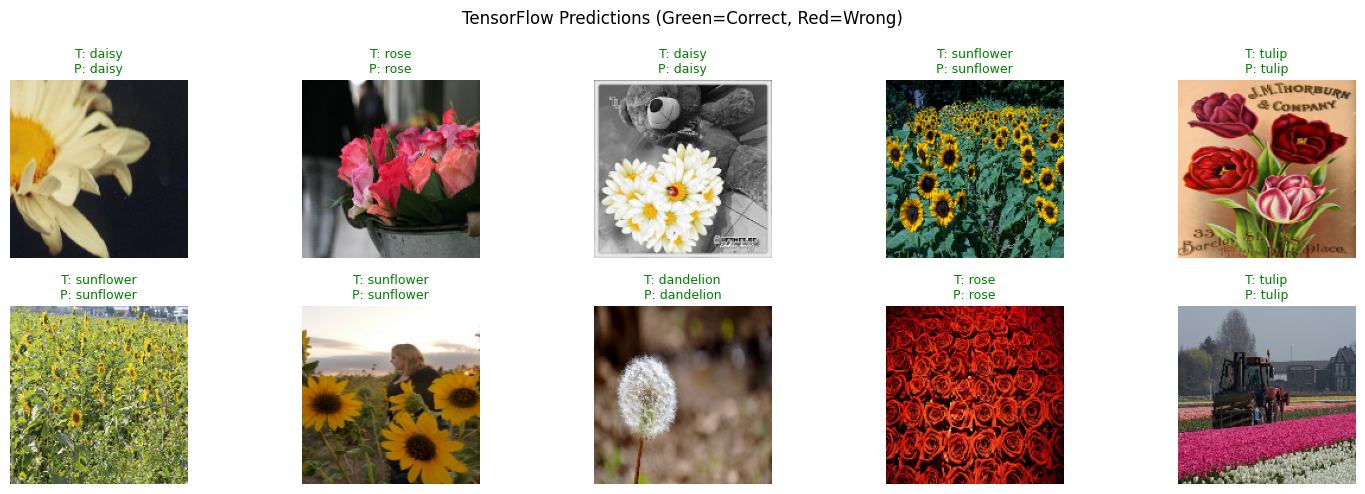

In [18]:
# Show sample test predictions — TensorFlow
n_samples = 10
idxs = random.sample(range(len(x_test)), n_samples)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(idxs):
    img_rgb = cv2.cvtColor(x_test[idx], cv2.COLOR_BGR2RGB)
    true_label = CLASS_NAMES[y_true_tf[idx]]
    pred_label = CLASS_NAMES[y_pred_tf[idx]]
    color = 'green' if true_label == pred_label else 'red'

    plt.subplot(2, 5, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"T: {true_label}\nP: {pred_label}",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("TensorFlow Predictions (Green=Correct, Red=Wrong)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
tf_model.save("flower_classifier_tensorflow.keras")

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE_TORCH = 224
BATCH_SIZE_TORCH = 32

# Training transforms (with augmentation)
torch_train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE_TORCH, IMG_SIZE_TORCH)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
torch_eval_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE_TORCH, IMG_SIZE_TORCH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Using device: cuda


In [21]:
class FlowerDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = np.argmax(labels, axis=1)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

In [22]:
train_dataset_torch = FlowerDataset(x_train, y_train, transform=torch_train_tfms)
val_dataset_torch   = FlowerDataset(x_val, y_val, transform=torch_eval_tfms)
test_dataset_torch  = FlowerDataset(x_test, y_test, transform=torch_eval_tfms)

train_loader = DataLoader(train_dataset_torch, batch_size=BATCH_SIZE_TORCH, shuffle=True)
val_loader   = DataLoader(val_dataset_torch, batch_size=BATCH_SIZE_TORCH, shuffle=False)
test_loader  = DataLoader(test_dataset_torch, batch_size=BATCH_SIZE_TORCH, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 81
Validation batches: 21
Test batches: 34


In [23]:
torch_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_features = torch_model.fc.in_features
torch_model.fc = nn.Linear(num_features, len(CLASS_NAMES))

# Freeze all layers except final classifier
for name, param in torch_model.named_parameters():
    if not name.startswith("fc."):
        param.requires_grad = False

torch_model = torch_model.to(device)

print(torch_model)

total_params = sum(p.numel() for p in torch_model.parameters())
trainable_params = sum(p.numel() for p in torch_model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
from sklearn.metrics import accuracy_score

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    total_loss = 0.0
    all_true, all_pred = [], []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_true.extend(y_batch.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_pred)
    return avg_loss, acc, np.array(all_true), np.array(all_pred)

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, torch_model.parameters()),
    lr=0.001
)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0
best_state = None
patience = 3
wait = 0
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc, _, _ = run_epoch(torch_model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = run_epoch(torch_model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu() for k, v in torch_model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    torch_model.load_state_dict(best_state)

Epoch 1/20 | Train Acc: 0.6983 | Val Acc: 0.8318
Epoch 2/20 | Train Acc: 0.8393 | Val Acc: 0.8441
Epoch 3/20 | Train Acc: 0.8590 | Val Acc: 0.8719
Epoch 4/20 | Train Acc: 0.8656 | Val Acc: 0.8781
Epoch 5/20 | Train Acc: 0.8864 | Val Acc: 0.8920
Epoch 6/20 | Train Acc: 0.8946 | Val Acc: 0.8873
Epoch 7/20 | Train Acc: 0.8965 | Val Acc: 0.8951
Epoch 8/20 | Train Acc: 0.8942 | Val Acc: 0.9090
Epoch 9/20 | Train Acc: 0.9046 | Val Acc: 0.9043
Epoch 10/20 | Train Acc: 0.9154 | Val Acc: 0.9105
Epoch 11/20 | Train Acc: 0.9239 | Val Acc: 0.9059
Epoch 12/20 | Train Acc: 0.9189 | Val Acc: 0.9028
Epoch 13/20 | Train Acc: 0.9231 | Val Acc: 0.9105
Early stopping triggered.


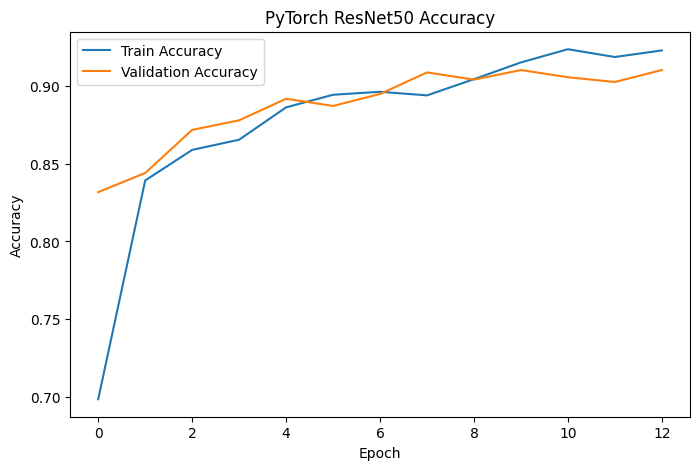

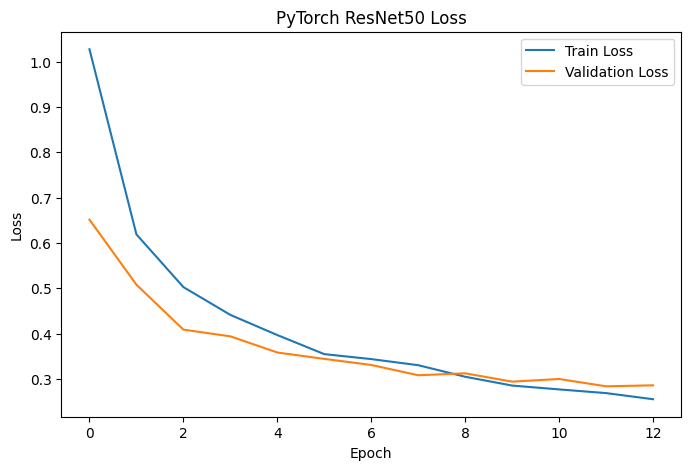

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("PyTorch ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("PyTorch ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix

test_loss, test_acc, y_true_torch, y_pred_torch = run_epoch(
    torch_model, test_loader, criterion
)

torch_prec, torch_rec, torch_f1, _ = precision_recall_fscore_support(
    y_true_torch, y_pred_torch, average="macro"
)

print("PyTorch Test Accuracy:", test_acc)
print("PyTorch Precision:", torch_prec)
print("PyTorch Recall:", torch_rec)
print("PyTorch F1-score:", torch_f1)

print("\nClassification Report:\n")
print(classification_report(y_true_torch, y_pred_torch, target_names=CLASS_NAMES))

PyTorch Test Accuracy: 0.8814814814814815
PyTorch Precision: 0.8829898246817045
PyTorch Recall: 0.8779847410012502
PyTorch F1-score: 0.8799000308917959

Classification Report:

              precision    recall  f1-score   support

       daisy       0.89      0.87      0.88       191
   dandelion       0.93      0.90      0.92       263
        rose       0.88      0.85      0.87       196
   sunflower       0.89      0.85      0.87       184
       tulip       0.83      0.91      0.87       246

    accuracy                           0.88      1080
   macro avg       0.88      0.88      0.88      1080
weighted avg       0.88      0.88      0.88      1080



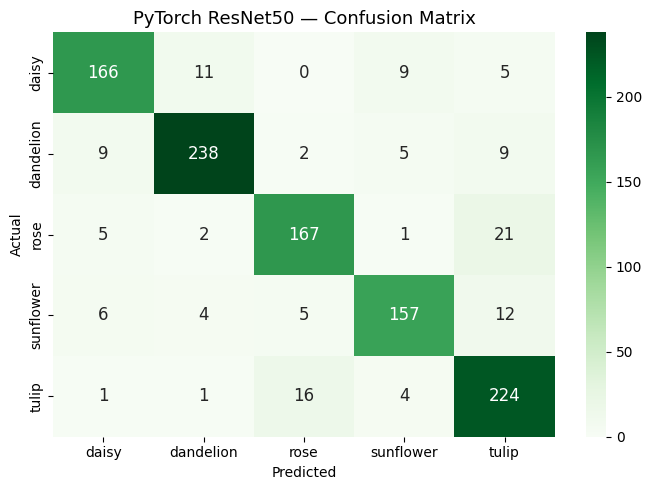

In [28]:
cm_torch = confusion_matrix(y_true_torch, y_pred_torch)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_torch, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            annot_kws={"size": 12})
plt.title("PyTorch ResNet50 — Confusion Matrix", fontsize=13)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [29]:
torch.save(torch_model.state_dict(), "flower_classifier_pytorch.pt")
print("PyTorch model saved successfully.")

PyTorch model saved successfully.


In [30]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Framework": "TensorFlow",
        "Accuracy": tf_acc,
        "Precision": tf_prec,
        "Recall": tf_rec,
        "F1-score": tf_f1
    },
    {
        "Framework": "PyTorch",
        "Accuracy": test_acc,
        "Precision": torch_prec,
        "Recall": torch_rec,
        "F1-score": torch_f1
    }
])

comparison

,Framework,Accuracy,Precision,Recall,F1-score
0,TensorFlow,0.860185,0.862284,0.853888,0.856879
1,PyTorch,0.881481,0.882990,0.877985,0.879900
